# EDA on Life Style Data

## John Edwin Guerrero Ayala

## Life Style Data - Data set to be used

* link  https://www.kaggle.com/datasets/jockeroika/life-style-data

* Data collection to do recommendations systems and App

## Kaggle notebook:

* link https://www.kaggle.com/code/seki32/personalized-diet-and-workout-recommendation

## Reference

### 1. Body Mass Index (BMI)
The universal formula used to calculate weight-to-height ratio:

$$BMI = \frac{\text{Weight (kg)}}{\left(\text{Height (m)}\right)^2}$$

### 2. Clinical Boer Formula (Age-Extended)
The clinically validated equations developed by Boer (1984) to estimate total Lean Body Mass (LBM), incorporating age-related degradation coefficients:

#### For Males:
$$\text{eLBM}_{\text{Male}} = 0.407 \times \text{Weight (kg)} + 0.267 \times \text{Height (cm)} - 0.192 \times \text{Age} - 19.2$$

#### For Females:
$$\text{eLBM}_{\text{Female}} = 0.252 \times \text{Weight (kg)} + 0.473 \times \text{Height (cm)} - 0.013 \times \text{Age} - 48.3$$

### 3. Skeletal Muscle Mass (SMM) and Muscle Percentage
Using the anthropometric distribution constants established by Janssen et al. (2000), skeletal muscle mass is isolated as a median $55\%$ structural fraction of total fat-free lean body mass:

$$\text{Estimated Muscle Mass (kg)} = \text{eLBM} \times 0.55$$

$$\text{Muscle Percentage (\%)} = \left( \frac{\text{Estimated Muscle Mass (kg)}}{\text{Weight (kg)}} \right) \times 100$$

### 4. Macronutrient Caloric Contribution (Protein Ratio)
To transform raw absolute nutritional metrics into relative metabolic features, the protein-to-calorie density is calculated using the standard physiological constraint of 4 kcal per gram of protein:

$$\text{Protein Calorie Ratio (\%)} = \frac{\text{Protein (g)} \times 4}{\text{Total Daily Calories (kcal)}} \times 100$$

## Goal

Train a neural network to predict users's diet and workout choices based on BMI vs Fat paradox

### Advanced, Age-Aware Body Composition Decision Matrix

| Condition 1 (BMI) | Condition 2 (Fat %) | Condition 3 (Muscle %) | Condition 4 (Age Group) | Physical Profile / Paradox Addressed | Model Target Output (Class) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **$\ge$ 25** (Overweight) | **$\le$ 20%** (Low/Fit) | **High** ($\ge 38\%$ Men / $\ge 30\%$ Women) | **Young / Adult** (All ages) | **The Muscular Athlete:** High weight-to-height ratio driven entirely by skeletal muscle mass, not adipose tissue. | `"Strength Maintenance & High Protein"` |
| **< 25** (Normal/Low) | **> 24%** (High) | **Low** ($< 33\%$ Men / $< 25\%$ Women) | **Young / Adult** (All ages) | **"Skinny Fat" (Normal Weight Obesity):** Scale weight appears healthy, but structurally lacking functional muscle mass. | `"Body Recomposition (Lose Fat + Gain Muscle)"` |
| **$\ge$ 25** (Overweight) | **> 20%** (Young)<br>**> 24%** (Older) | **Low to Moderate** | **Older Adult** ($\ge 50$ yrs) | **Age-Adjusted Overweight:** True metabolic risk profile, adjusting fat thresholds upward to allow for natural aging baselines. | `"Caloric Deficit & Cardio Focus"` |
| *Any other baseline* | *Healthy range for age* | *Healthy range for age* | **Any Age** | **Lean / Balanced Fit:** Baseline profile with an optimal, functional balance of fat and muscle mass for their specific age bracket. | `"Lean Mass Bulking"` |

## Reference studies

1. **BMI Limitations & Paradoxes:**
   * [Medical News Today: BMI vs. Body Fat Percentage](https://www.medicalnewstoday.com/articles/body-fat-percentage-chart) - Clinical context on normal weight obesity ("skinny fat") and athlete misclassifications.

2. **Lean Body Mass Engineering & Formula Verification:**
   * [Omni Calculator: Lean Body Mass Tool](https://www.omnicalculator.com/health/lean-body-mass) - An interactive educational reference breaking down the exact coefficients of the Boer and Hume linear equations for both sexes.
   * [BodySpec: Ultimate Lean Body Mass Calculator Guide](https://www.bodyspec.com/blog/post/ultimate_lean_body_mass_calculator_boer_james_hume_peters_formulas) - A simplified fitness resource explaining how clinical equations (Boer 1984) translate raw metrics into target parameters like protein needs and muscle splits.

3. **Skeletal Muscle Estimation Scaling:**
   * [Janssen, et al. (2000) via Journal of Applied Physiology](https://journals.physiology.org/doi/full/10.1152/jappl.2000.89.1.81) - Whole-body MRI baseline data justifying the 55% median scaling constant used to extract pure skeletal muscle mass fractions from fat-free lean tissue.


## Preprocessing

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib, os
from typing import Dict, Any
import os

%matplotlib inline

In [2]:
path = kagglehub.dataset_download('jockeroika/life-style-data')

print(path)

/Users/johnwarrior/.cache/kagglehub/datasets/jockeroika/life-style-data/versions/7


In [3]:
print(os.listdir(path))

['Final_data.csv', 'meal_metadata.csv']


In [4]:
df = pd.read_csv(os.path.join(path, 'Final_data.csv'))
df_meal_metadata = pd.read_csv(os.path.join(path, 'meal_metadata.csv'))


## Data Exploration

In [5]:
df.head()

df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,38.851454,73.898832,1.723094,179.889702,143.704306,62.195813,1.259446,1280.109601,26.101313,2.627486,...,24.921651,1998.297076,0.499983,1.460142,0.699005,0.802305,744.308699,53.786384,866.352318,8.631802e+19
std,12.114580,21.173010,0.127033,11.510805,14.267688,7.289351,0.341336,502.228982,4.996160,0.604724,...,6.701144,440.848408,0.001455,0.518946,0.144880,0.096613,720.946619,12.498740,250.317069,3.197579e+19
min,18.000000,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,11.333134,1.460000,...,12.037907,1105.570000,0.492434,0.516706,0.371344,0.599789,-1266.220000,30.946261,219.852800,2.491905e+16
25%,28.170000,58.160000,1.620000,170.057500,131.220000,55.960000,1.050000,910.800000,22.387807,2.170000,...,20.094975,1661.022500,0.499054,1.076294,0.583656,0.727676,261.432500,44.587037,714.098250,6.441978e+19
50%,39.865000,70.000000,1.710000,180.140000,142.990000,62.200000,1.270000,1231.450000,25.822504,2.610000,...,24.119097,1943.130000,0.499981,1.382260,0.686284,0.794834,691.190000,51.204908,868.721400,8.371578e+19
75%,49.630000,86.100000,1.800000,189.425000,156.060000,68.090000,1.460000,1553.112500,29.676026,3.120000,...,28.562620,2271.950000,0.500910,1.750495,0.798196,0.869211,1176.290000,61.939016,1012.532700,1.100442e+20
max,59.670000,130.770000,2.010000,199.640000,169.840000,74.500000,2.020000,2890.820000,35.000000,3.730000,...,50.229544,3699.540000,0.507889,3.916881,1.073939,1.047032,3075.580000,90.117371,1477.108800,1.756614e+20


In [6]:
df_meal_metadata.head()

df_meal_metadata.info()

df_meal_metadata.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             168 non-null    float64
 1   Gender                          168 non-null    object 
 2   Weight (kg)                     168 non-null    float64
 3   Height (m)                      168 non-null    float64
 4   Max_BPM                         168 non-null    float64
 5   Avg_BPM                         168 non-null    float64
 6   Resting_BPM                     168 non-null    float64
 7   Session_Duration (hours)        168 non-null    float64
 8   Calories_Burned                 168 non-null    float64
 9   Workout_Type                    168 non-null    object 
 10  Fat_Percentage                  168 non-null    float64
 11  Water_Intake (liters)           168 non-null    float64
 12  Workout_Frequency (days/week)   168 

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.00000,168.000000,168.000000,168.000000,168.000000,...,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,1.680000e+02
mean,37.044762,73.893155,1.730833,180.139821,142.081786,60.94244,1.315417,1370.808631,26.109405,2.644405,...,24.629672,1992.388988,0.500047,1.440333,0.688136,0.792242,653.881845,53.938790,892.938881,8.266275e+19
std,11.255715,19.640965,0.127460,11.048849,14.392953,7.36604,0.342040,544.205792,4.674788,0.617245,...,5.706437,440.916018,0.001419,0.484944,0.144928,0.098914,735.365526,11.984852,263.671269,3.206140e+19
min,18.000000,40.940000,1.500000,160.090000,120.040000,49.83000,0.540000,356.080000,14.841976,1.490000,...,12.783934,1231.770000,0.495986,0.580890,0.376148,0.605681,-997.460000,33.685616,345.933000,2.703950e+16
25%,28.097500,58.075000,1.620000,170.720000,129.832500,54.56000,1.100000,984.675000,22.687502,2.205000,...,20.444702,1650.427500,0.499029,1.111802,0.582638,0.715800,172.957500,44.230534,726.417450,6.543995e+19
50%,36.955000,71.450000,1.730000,180.230000,139.510000,60.90000,1.320000,1294.920000,26.643963,2.690000,...,24.160016,1951.840000,0.500277,1.364233,0.665148,0.771664,582.395000,53.244962,885.427200,8.063849e+19
75%,45.975000,86.440000,1.820000,189.547500,155.857500,66.90000,1.500000,1757.535000,29.406536,3.225000,...,28.019273,2287.960000,0.500941,1.669344,0.783878,0.861027,1157.065000,61.934583,1063.357800,1.032237e+20
max,58.240000,127.920000,2.000000,199.210000,168.710000,74.26000,2.000000,2851.200000,35.000000,3.600000,...,42.617528,3426.160000,0.503448,2.931363,1.069165,1.044038,2491.420000,89.840141,1379.516600,1.505159e+20


In [7]:
df['Gender'].unique()
df['Gender'] = df['Gender'].apply(lambda x:1 if x =="Male" else 0)

In [8]:
df['diet_type'].unique()

array(['Vegan', 'Vegetarian', 'Paleo', 'Keto', 'Low-Carb', 'Balanced'],
      dtype=object)

In [9]:
df['cooking_method'].unique()

array(['Grilled', 'Fried', 'Boiled', 'Baked', 'Steamed', 'Raw', 'Roasted'],
      dtype=object)

In [10]:
df['Fat_Percentage'].describe()


count    20000.000000
mean        26.101313
std          4.996160
min         11.333134
25%         22.387807
50%         25.822504
75%         29.676026
max         35.000000
Name: Fat_Percentage, dtype: float64

<Axes: title={'center': 'BMI summary'}>

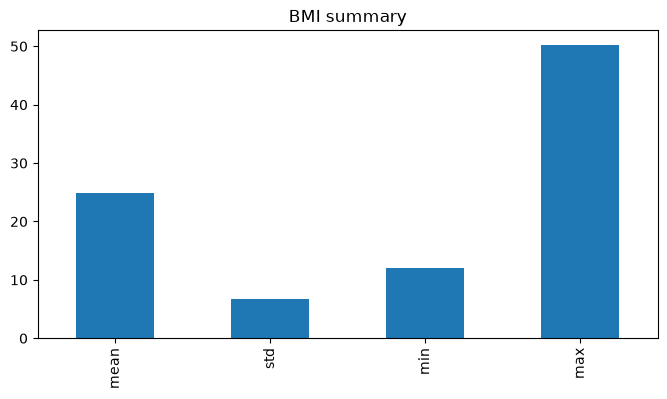

In [11]:
stats_bmi = df['BMI'].describe()[['mean', 'std', 'min', 'max']]
stats_bmi.plot(kind='bar', figsize=(8, 4), title='BMI summary')

<Axes: title={'center': 'Fat_Percentage summary'}>

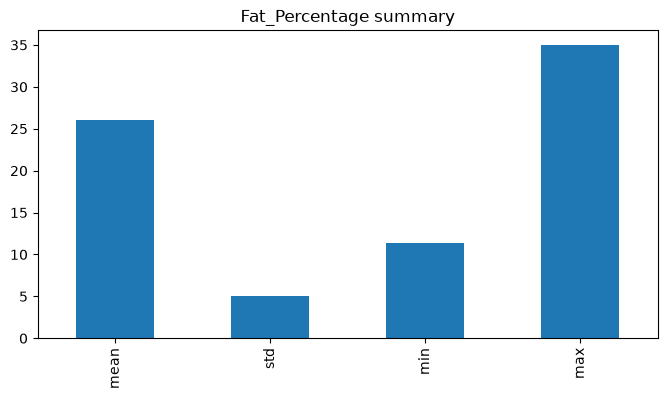

In [12]:
stats_fat_percentage = df['Fat_Percentage'].describe()[['mean', 'std', 'min', 'max']]
stats_fat_percentage.plot(kind='bar', figsize=(8, 4), title='Fat_Percentage summary')

<Axes: title={'center': 'Age summary'}>

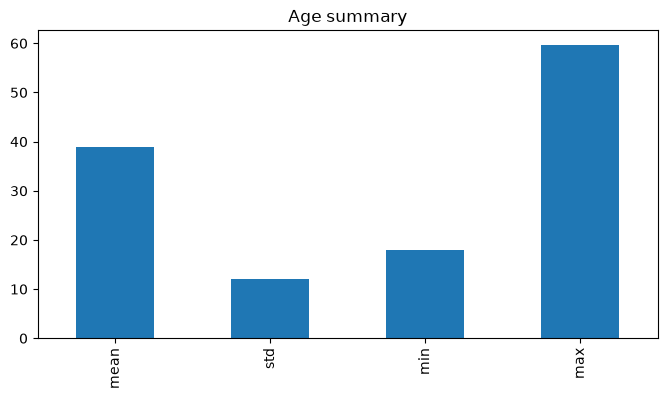

In [13]:
stats_age = df['Age'].describe()[['mean', 'std', 'min', 'max']]
stats_age.plot(kind='bar', figsize=(8, 4), title='Age summary')

## Gender Distribution

=== Demographic Breakdown ===
Total Males   (1): 9,972 (49.9%)
Total Females (0): 10,028 (50.1%)
Total Dataset Size: 20,000



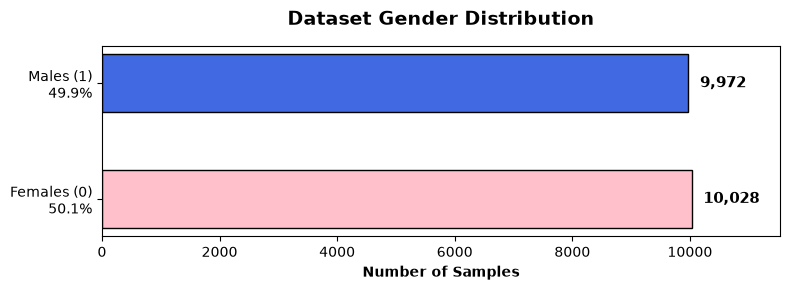

In [14]:
gender_counts = df['Gender'].value_counts()
total_samples = len(df)

male_count = gender_counts.get(1, 0)
female_count = gender_counts.get(0, 0)

male_pct = (male_count / total_samples) * 100
female_pct = (female_count / total_samples) * 100

# 2. Print out a clean text summary for your notes
print("=== Demographic Breakdown ===")
print(f"Total Males   (1): {male_count:,} ({male_pct:.1f}%)")
print(f"Total Females (0): {female_count:,} ({female_pct:.1f}%)")
print(f"Total Dataset Size: {total_samples:,}\n")

# 3. Plot the distribution as a clean bar chart
plt.figure(figsize=(8, 3))

# Define labels and values mapping back to strings
labels = [f'Males (1)\n{male_pct:.1f}%', f'Females (0)\n{female_pct:.1f}%']
values = [male_count, female_count]
colors = ['royalblue', 'pink']

# Create horizontal bar chart
bars = plt.barh(labels, values, color=colors, edgecolor='black', height=0.5)

# Add exact value labels inside or next to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (total_samples * 0.01),  # Slight offset to the right
             bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', 
             va='center', ha='left', fontweight='bold', fontsize=11)

plt.title('Dataset Gender Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Samples', fontweight='bold')
plt.xlim(0, max(values) * 1.15)  # Leave extra room for the text labels
plt.gca().invert_yaxis()         # Keep Males on top to match standard orders
plt.tight_layout()
plt.show()

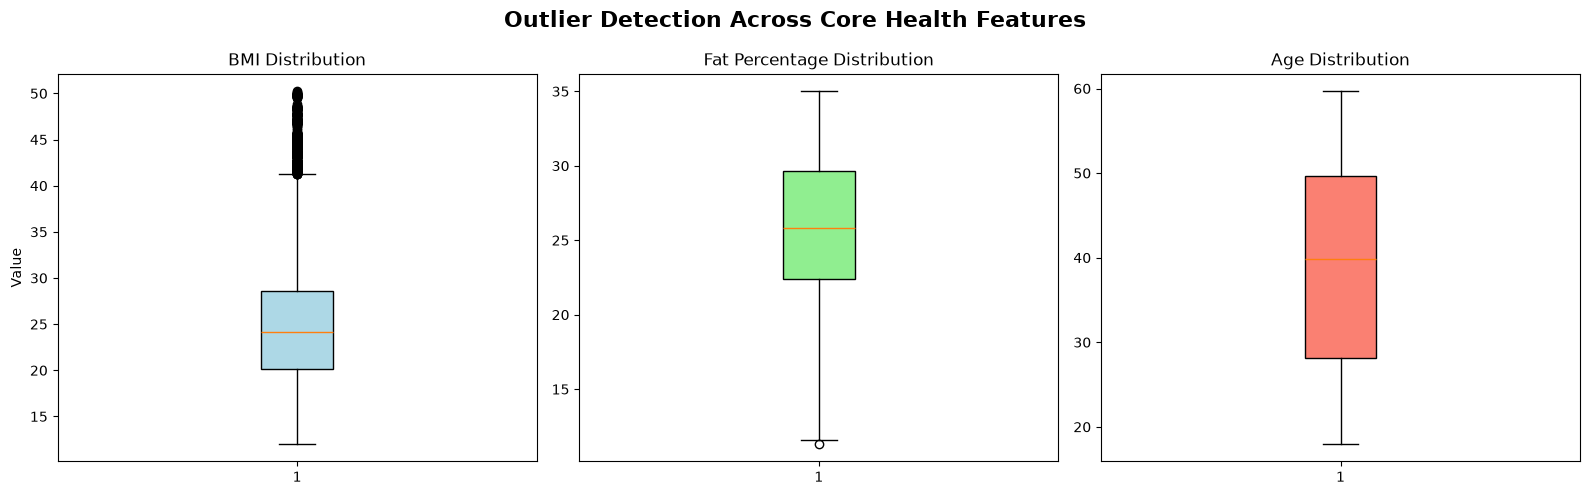

In [15]:
# Create a figure frame for our box plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Outlier Detection Across Core Health Features', fontsize=16, fontweight='bold')

# Feature 1: BMI Box Plot
axes[0].boxplot(df['BMI'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'))
axes[0].set_title('BMI Distribution')
axes[0].set_ylabel('Value')

# Feature 2: Fat Percentage Box Plot
axes[1].boxplot(df['Fat_Percentage'], patch_artist=True, boxprops=dict(facecolor='lightgreen', color='black'))
axes[1].set_title('Fat Percentage Distribution')

# Feature 3: Age Box Plot
axes[2].boxplot(df['Age'], patch_artist=True, boxprops=dict(facecolor='salmon', color='black'))
axes[2].set_title('Age Distribution')

plt.tight_layout()
plt.show()

In [16]:
super_high_bmi_count = len(df[df['BMI'] > 40])
percentage = (super_high_bmi_count / len(df)) * 100

print(f"Number of individuals with BMI > 40: {super_high_bmi_count:,}")
print(f"Percentage of the dataset: {percentage:.2f}%")



Number of individuals with BMI > 40: 715
Percentage of the dataset: 3.57%


In [17]:
# Filter the dataset to keep realistic, standard distributions
df = df[df['BMI'] <= 40]

## FEATURE ENGINEERING
### Convert height to centimeters to match standard clinical coefficients

In [18]:
df['Height_cm'] = df['Height (m)'] * 100

### Clinical Boer Formula with Explicit Age Multipliers

In [19]:
# Calculate eLBM via Boer Formula
df['eLBM'] = np.where(
    df['Gender'] == 1,
    (0.407 * df['Weight (kg)']) + (0.267 * df['Height_cm']) - (0.192 * df['Age']) - 19.2,
    (0.252 * df['Weight (kg)']) + (0.473 * df['Height_cm']) - (0.013 * df['Age']) - 48.3
)

### Skeletal Muscle Mass Estimation (Janssen 55% Scaling Constant)

In [20]:

df['Estimated_Muscle_Mass_kg'] = np.where(
    df['Gender'] == 1,
    df['eLBM'] * 0.57,  # Men: Muscle tissue is a higher fraction of LBM
    df['eLBM'] * 0.48   # Women: Organs/fluids are a higher fraction of LBM
)
df['Muscle_Percentage'] = (df['Estimated_Muscle_Mass_kg'] / df['Weight (kg)']) * 100


### Nutritional Intensity Feature Engineering

In [21]:

df['Protein_Per_KG'] = df['Proteins'] / df['Weight (kg)']
df['Protein_Calorie_Percentage'] = (df['Proteins'] * 4) / df['Calories']

### Decision Matrix

In [22]:

def assign_advanced_age_recommendation(row):
    bmi = row['BMI']
    fat = row['Fat_Percentage']
    muscle = row['Muscle_Percentage']
    age = row['Age']
    
    # Updated: Check for 1 instead of the string "Male"
    is_male = (row['Gender'] == 1) 
    
    # 1. Establish Gender-Aware Muscle Thresholds
    high_muscle = muscle >= 38 if is_male else muscle >= 30
    low_muscle = muscle < 33 if is_male else muscle < 25
    
    # 2. Establish Dynamic, Age-Aware Fat Thresholds 
    fat_threshold = 24 if age >= 50 else 20

    # 3. Non-linear Target Mapping Logic
    if bmi >= 25 and fat <= fat_threshold and high_muscle:
        return "Strength Maintenance & High Protein"
        
    elif bmi < 25 and fat > (fat_threshold + 4) and low_muscle:
        return "Body Recomposition (Lose Fat + Gain Muscle)"
        
    elif bmi >= 25 and fat > fat_threshold:
        return "Caloric Deficit & Cardio Focus"
        
    else:
        return "Lean Mass Bulking"

# Apply programmatic recommendation to establish the target values
df['Recommendation'] = df.apply(assign_advanced_age_recommendation, axis=1)

## Exploratory Data Analysis

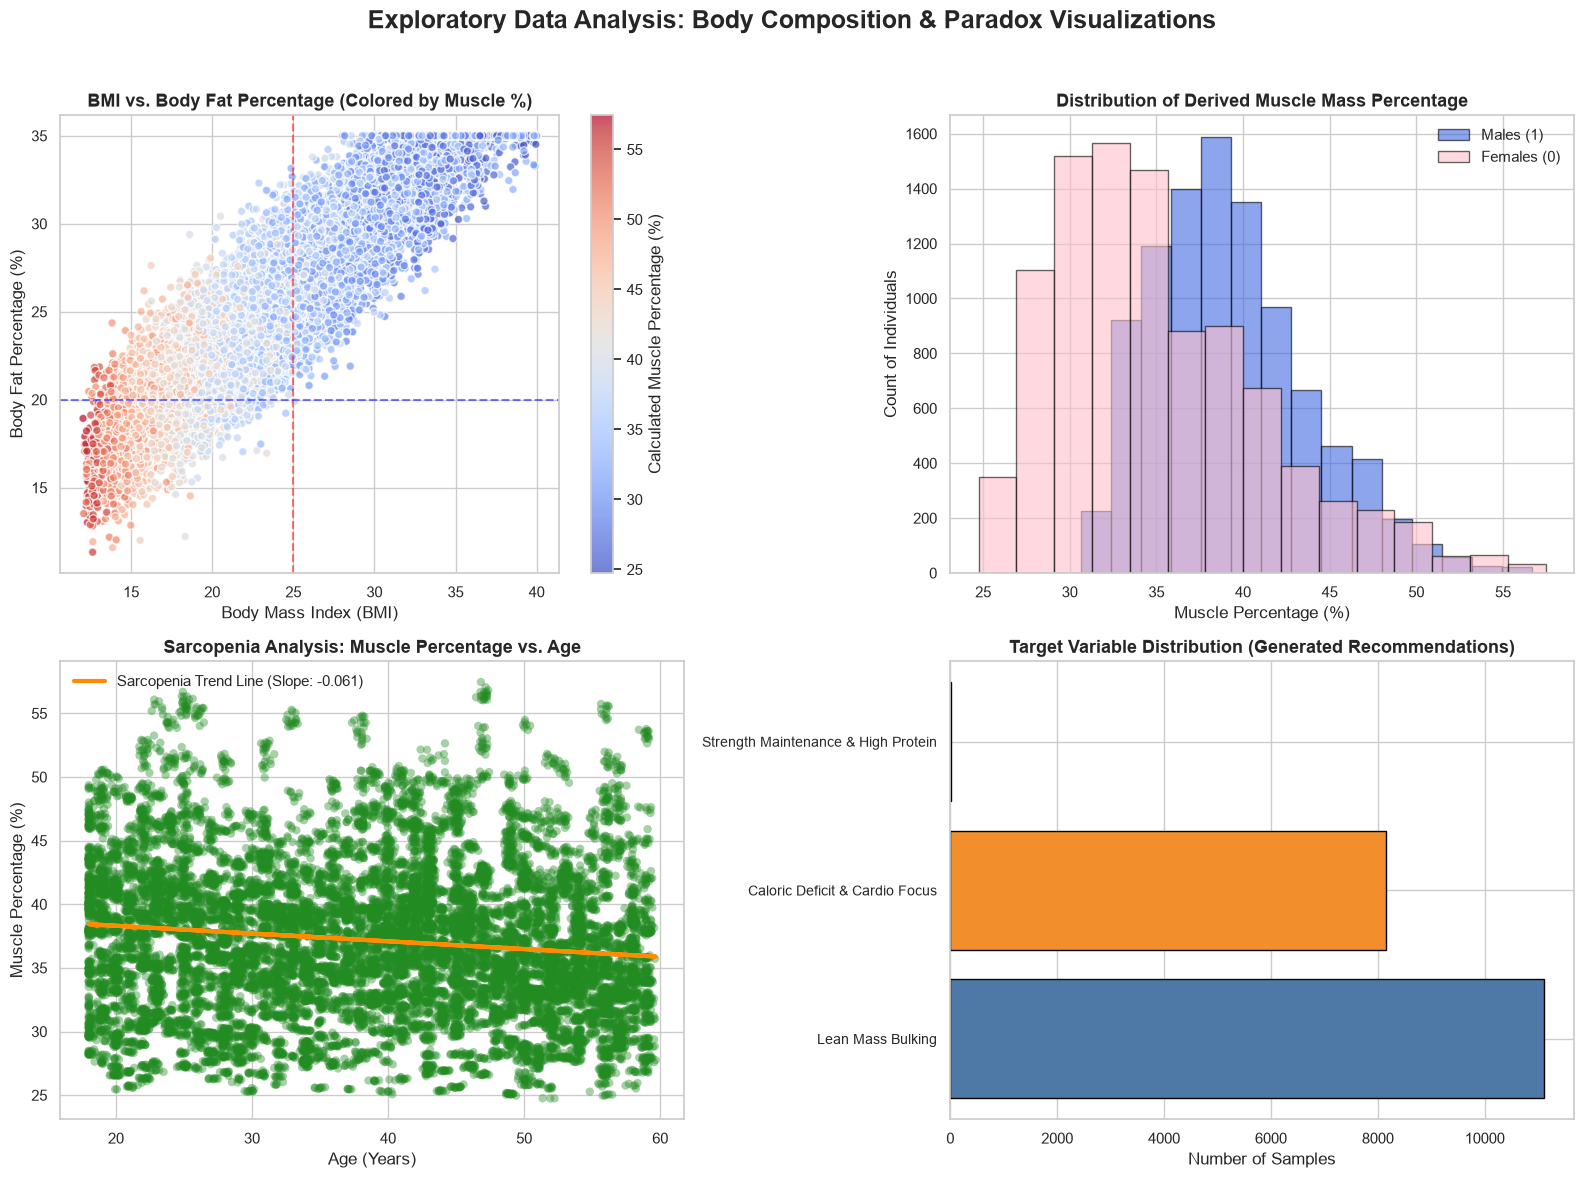

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a clean, academic style for the plots
# Fixed: Removed the parenthesis after plt.style.available
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")

# Create a large multi-plot figure frame (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis: Body Composition & Paradox Visualizations', fontsize=18, fontweight='bold')

# =====================================================================
# PLOT 1: The BMI vs. Fat Percentage Scatter Plot (Visualizing the Paradox)
# =====================================================================
ax1 = axes[0, 0]
scatter = ax1.scatter(df['BMI'], df['Fat_Percentage'], c=df['Muscle_Percentage'], cmap='coolwarm', alpha=0.7, edgecolors='w')
ax1.set_title('BMI vs. Body Fat Percentage (Colored by Muscle %)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Body Mass Index (BMI)')
ax1.set_ylabel('Body Fat Percentage (%)')
# Add a color bar to show muscle intensity
cbar = fig.colorbar(scatter, ax=ax1)
cbar.set_label('Calculated Muscle Percentage (%)')

# Add threshold lines to highlight your 4 matrix quadrants
ax1.axvline(25, color='red', linestyle='--', alpha=0.5, label='Overweight Threshold (BMI=25)')
ax1.axhline(20, color='blue', linestyle='--', alpha=0.5, label='Fit Fat Threshold (20%)')


# =====================================================================
# PLOT 2: Distribution of Engineered Muscle Percentage Across Genders
# =====================================================================
ax2 = axes[0, 1]

# Separate data using your encoded numbers (1 for Male, 0 for Female)
males = df[df['Gender'] == 1]['Muscle_Percentage']
females = df[df['Gender'] == 0]['Muscle_Percentage']

# Plot the histograms
ax2.hist(males, bins=15, alpha=0.6, label='Males (1)', color='royalblue', edgecolor='black')
ax2.hist(females, bins=15, alpha=0.6, label='Females (0)', color='pink', edgecolor='black')

ax2.set_title('Distribution of Derived Muscle Mass Percentage', fontsize=13, fontweight='bold')
ax2.set_xlabel('Muscle Percentage (%)')
ax2.set_ylabel('Count of Individuals')
ax2.legend()


# =====================================================================
# PLOT 3: Age-Related Muscle Decline (Sarcopenia Verification)
# =====================================================================
ax3 = axes[1, 0]
# Calculate a trendline to show muscle vs age
x_age = df['Age']
y_muscle = df['Muscle_Percentage']
m, b = np.polyfit(x_age, y_muscle, 1) # Linear regression line

ax3.scatter(x_age, y_muscle, color='forestgreen', alpha=0.4, edgecolors='none')
ax3.plot(x_age, m*x_age + b, color='darkorange', linewidth=3, label=f'Sarcopenia Trend Line (Slope: {m:.3f})')
ax3.set_title('Sarcopenia Analysis: Muscle Percentage vs. Age', fontsize=13, fontweight='bold')
ax3.set_xlabel('Age (Years)')
ax3.set_ylabel('Muscle Percentage (%)')
ax3.legend()


# =====================================================================
# PLOT 4: Target Class Balance (Checking Class Distribution for the NN)
# =====================================================================
ax4 = axes[1, 1]
class_counts = df['Recommendation'].value_counts()
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# Let pandas/matplotlib handle the tick mapping natively to avoid tick errors
ax4.barh(class_counts.index, class_counts.values, color=colors, edgecolor='black')
ax4.set_title('Target Variable Distribution (Generated Recommendations)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Number of Samples')

# Clean and secure way to style tick parameters without breaking positioning math
ax4.tick_params(axis='y', labelsize=10)

# Automatically adjust spacing between plots so text doesn't overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Neural Network

### Neural Network preparation

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Separate your continuous numerical columns from the binary indicator
continuous_cols = [
    'Age', 'BMI', 'Fat_Percentage', 'eLBM', 
    'Muscle_Percentage', 'Protein_Per_KG', 'Protein_Calorie_Percentage'
]

X_continuous = df[continuous_cols]
X_gender = df['Gender'] # Already 1s and 0s

encoder = LabelEncoder()
df['Target_Label'] = encoder.fit_transform(df['Recommendation'])
y = df['Target_Label']

# 2. Train / Test Split everything using the identical random state
X_train_cont, X_test_cont, gender_train, gender_test, y_train, y_test = train_test_split(
    X_continuous, X_gender, y, test_size=0.2, random_state=42
)

# 3. Fit and scale ONLY the continuous physiological measurements
scaler = StandardScaler()
X_train_cont_scaled = scaler.fit_transform(X_train_cont)
X_test_cont_scaled = scaler.transform(X_test_cont)

# 4. Recombine by stitching the untouched 1/0 binary gender array to the scaled numbers
X_train_scaled = np.column_stack((X_train_cont_scaled, gender_train))
X_test_scaled = np.column_stack((X_test_cont_scaled, gender_test))

print(f"Perfectly prepared matrix shapes: {X_train_scaled.shape}")

Perfectly prepared matrix shapes: (15428, 8)


### Neural Network training

In [25]:
import tensorflow as tf
from tensorflow.keras import models, layers, callbacks

# ==========================================
# 5. NEURAL NETWORK ARCHITECTURE
# ==========================================
# Dynamically capture the number of input features (should be 8)
input_dimensions = X_train_scaled.shape[1]

model = models.Sequential([
    # Input Layer matching our custom scaled matrix
    layers.Input(shape=(input_dimensions,)),
    
    # Hidden Layer 1: Wide capacity to learn non-linear health metric overlaps
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2), # Prevents overfitting on dominant dataset clusters
    
    # Hidden Layer 2: Deeper representation abstraction
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    # Hidden Layer 3: Tight bottleneck layer before classification
    layers.Dense(16, activation='relu'),
    
    # Output Layer: 4 neurons matching our 4 decision matrix categories
    # Softmax outputs a clean probability distribution summing to 1.0
    layers.Dense(4, activation='softmax')
])

# ==========================================
# 6. COMPILATION SETTINGS
# ==========================================
model.compile(
    optimizer='adam',
    # Used because target labels (y) are integers (0, 1, 2, 3), not one-hot vectors
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# Print a professional architectural blueprint of your network
model.summary()

# ==========================================
# 7. MODEL OPTIMIZATION & TRAINING
# ==========================================
# Early stopping protects your validation split from overfitting during long runs
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("\nStarting Neural Network Training...")
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=40, 
    batch_size=32, 
    validation_split=0.15, # 15% internal validation to track real-time generalization
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 8. GENERALIZATION PERFORMANCE EVALUATION
# ==========================================
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("\n" + "="*40)
print(f"OPTIMIZATION COMPLETE")
print(f"Isolated Test Dataset Loss:     {test_loss:.4f}")
print(f"Isolated Test Dataset Accuracy: {test_acc * 100:.2f}%")
print("="*40)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,636 (14.20 KB)

 Trainable params: 3,444 (13.45 KB)

 Non-trainable params: 192 (768.00 B)


Starting Neural Network Training...
Epoch 1/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8704 - loss: 0.3676 - val_accuracy: 0.9793 - val_loss: 0.0780
Epoch 2/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - accuracy: 0.9511 - loss: 0.1271 - val_accuracy: 0.9801 - val_loss: 0.0651
Epoch 3/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step - accuracy: 0.9617 - loss: 0.0987 - val_accuracy: 0.9862 - val_loss: 0.0551
Epoch 4/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9662 - loss: 0.0879 - val_accuracy: 0.9914 - val_loss: 0.0447
Epoch 5/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - accuracy: 0.9730 - loss: 0.0743 - val_accuracy: 0.9866 - val_loss: 0.0424
Epoch 6/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.9780 - loss: 0.0617 - val_accuracy: 0.9888 - val_loss: 0.0376
Epoch 7/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.9790 - loss: 0.0595 - val_accuracy: 0.9914 - val_loss: 0.0325
Epoch 8/40
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - a

### Neural Network evaluation

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step


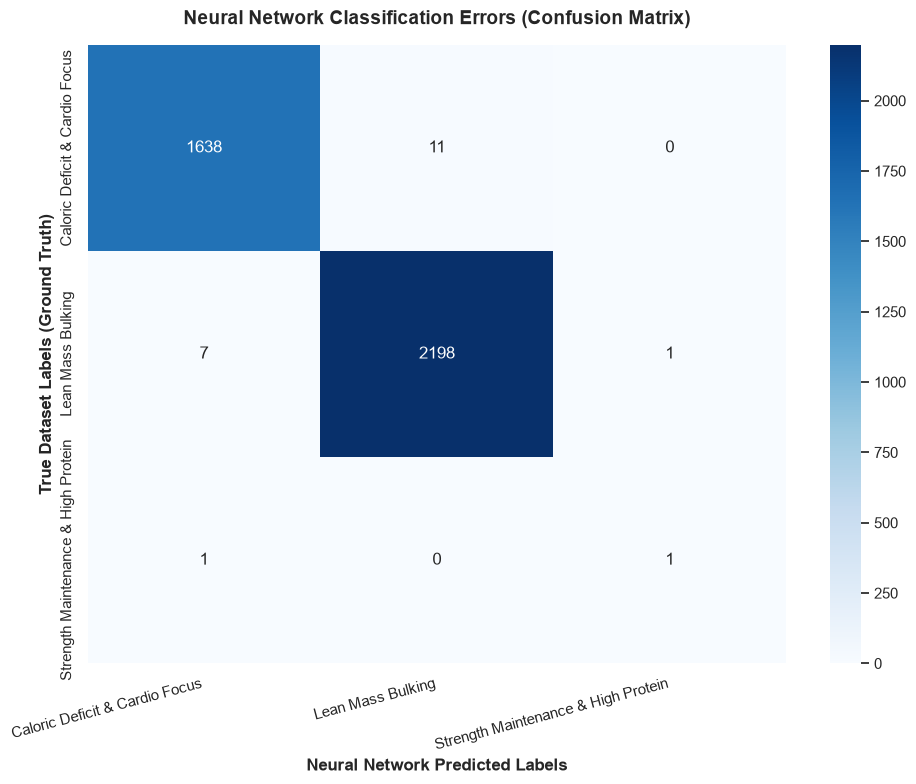


=== Classification Detailed Performance Metrics ===
                                     precision    recall  f1-score   support

     Caloric Deficit & Cardio Focus       1.00      0.99      0.99      1649
                  Lean Mass Bulking       1.00      1.00      1.00      2206
Strength Maintenance & High Protein       0.50      0.50      0.50         2

                           accuracy                           0.99      3857
                          macro avg       0.83      0.83      0.83      3857
                       weighted avg       0.99      0.99      0.99      3857



In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Generate model probability predictions on the test dataset
y_pred_probs = model.predict(X_test_scaled)

# 2. Convert raw probability vectors into absolute integer class predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 3. Calculate the confusion matrix array
cm = confusion_matrix(y_test, y_pred_classes)

# 4. Grab the original text names of your labels to keep the plot highly readable
# The encoder classes align perfectly with the integer mappings 0, 1, 2, 3
class_names = encoder.classes_

# 5. Plot the Error Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Neural Network Classification Errors (Confusion Matrix)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Dataset Labels (Ground Truth)', fontweight='bold')
plt.xlabel('Neural Network Predicted Labels', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# 6. Optional: Print an explicit precision/recall text audit right below it
print("\n=== Classification Detailed Performance Metrics ===")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

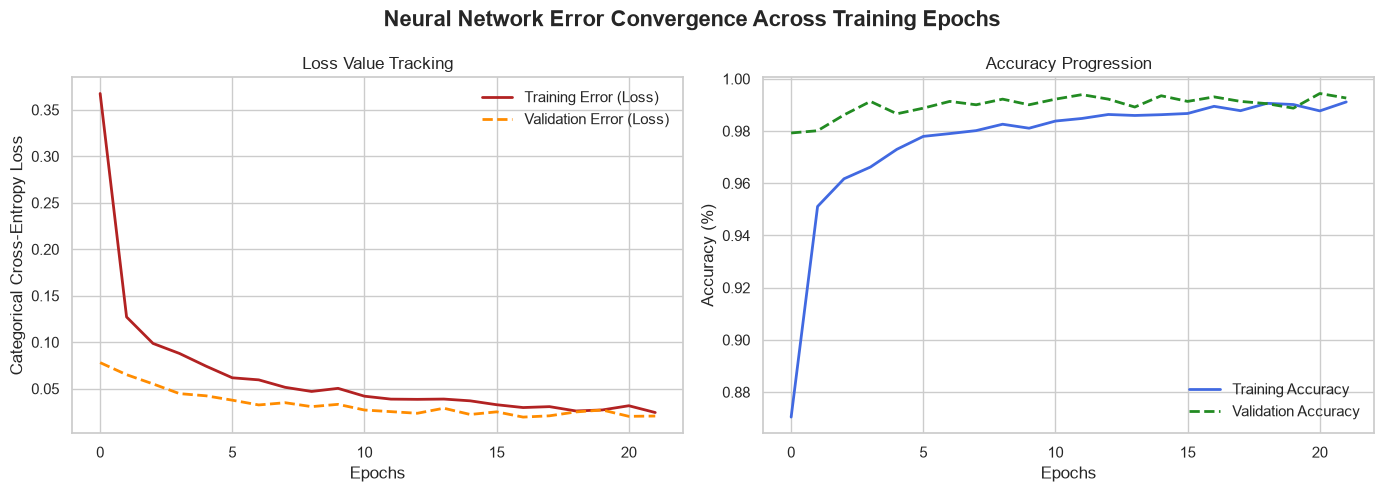

In [27]:
# Create a dashboard showing training error optimization over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Error Convergence Across Training Epochs', fontsize=16, fontweight='bold')

# Plot 1: Cross-Entropy Loss Curve (The direct measure of error)
ax1.plot(history.history['loss'], label='Training Error (Loss)', color='firebrick', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Error (Loss)', color='darkorange', linewidth=2, linestyle='--')
ax1.set_title('Loss Value Tracking')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Categorical Cross-Entropy Loss')
ax1.legend()

# Plot 2: Accuracy Development
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='royalblue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='forestgreen', linewidth=2, linestyle='--')
ax2.set_title('Accuracy Progression')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

## Testing the model with new data

In [28]:
profile = {
    'Age': 39,
    'Gender': 1,              # Male
    'Weight_kg': 78.05,
    'Height_cm': 183,
    'BMI': 23.3,
    'Fat_Percentage': 14.2,
    # Just for reference, not used in the model
    'Proteins_g': 150,        
    'Calories': 2500,
}

In [29]:
def build_single_input(profile):
    w = profile['Weight_kg']
    h = profile['Height_cm']
    age = profile['Age']
    gender = profile['Gender']
    # Boer eLBM (same as your notebook)
    if gender == 1:
        elbm = (0.407 * w) + (0.267 * h) - (0.192 * age) - 19.2
        muscle_kg = elbm * 0.57
    else:
        elbm = (0.252 * w) + (0.473 * h) - (0.013 * age) - 48.3
        muscle_kg = elbm * 0.48
    muscle_pct = (muscle_kg / w) * 100
    protein_per_kg = profile['Proteins_g'] / w
    protein_cal_pct = (profile['Proteins_g'] * 4) / profile['Calories']
    # Same column order as continuous_cols in your notebook
    row = pd.DataFrame([{
        'Age': age,
        'BMI': profile['BMI'],
        'Fat_Percentage': profile['Fat_Percentage'],
        'eLBM': elbm,
        'Muscle_Percentage': muscle_pct,
        'Protein_Per_KG': protein_per_kg,
        'Protein_Calorie_Percentage': protein_cal_pct,
    }])
    scaled = scaler.transform(row)          # uses training scaler
    X_single = np.column_stack([scaled, [gender]])  # add Gender as 8th feature
    return X_single, row
X_single, features_df = build_single_input(profile)
features_df.round(2)

,Age,BMI,Fat_Percentage,eLBM,Muscle_Percentage,Protein_Per_KG,Protein_Calorie_Percentage
0,39,23.3,14.2,53.94,39.39,1.92,0.24


In [30]:
probs = model.predict(X_single, verbose=0)[0]
pred_class = int(np.argmax(probs))
recommendation = encoder.inverse_transform([pred_class])[0]
print("Predicted class:", pred_class)
print("Recommendation:", recommendation)
print("Probabilities:")
for name, p in zip(encoder.classes_, probs):
    print(f"  {name}: {p:.2%}")

Predicted class: 1
Recommendation: Lean Mass Bulking
Probabilities:
  Caloric Deficit & Cardio Focus: 0.00%
  Lean Mass Bulking: 99.99%
  Strength Maintenance & High Protein: 0.00%
